Let's solve the following problem: a beam fixed at the left end and simply supported at the right end is not subjected to any external load. At $z = L_1$, the beam is subjected to a concentrated rotational distortion $D_{\phi}$ which introduces a rotational discontinuity. We apply the Euler-Bernoulli beam model to calculate the beam displacement.

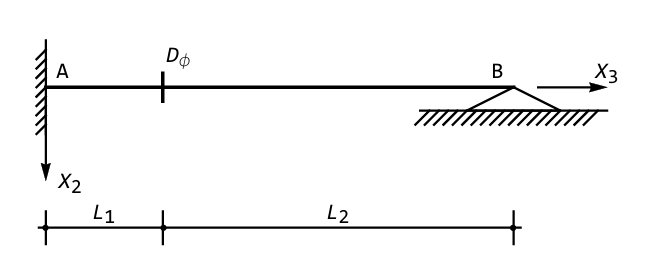

In [1]:
# Importing SymPy
import sympy as smp

In [2]:
# Defining symbols and functions
E, I, A, L1, L2, D = smp.symbols("E I A L1 L2 D_{phi}", real = True, positive = True, constant = True)
z = smp.symbols("z", real = True)
u1 = smp.Function("u_1", real = True)(z)
u2 = smp.Function("u_2", real = True)(z)

In [3]:
# Defining equations and solve the first unknowns
eq1 = smp.Eq(smp.diff(u1, z, 4), 0) # u1(z)'''' = 0 for 0 <= z <= L1
eq2 = smp.Eq(smp.diff(u2, z, 4), 0) # u2(z)'''' = 0 for L1 < z <= L1 + L2
eq = [eq1, eq2]

# Boundary conditions: fixed beam on the left (z = 0), simply supported beam on the right (z = L1 + L2)
ics = {
    u1.subs(z, 0): 0, # u1(0) = 0
    smp.diff(u1, z, 1).subs(z, 0): 0, # u1'(0) = 0

    u2.subs(z, L1 + L2): 0, # u2(L1 + L2) = 0
    smp.diff(u2, z, 2).subs(z, L1 + L2): 0 # u2''(L1 + L2) = 0
}

# Solution without considering the distorsion, for now
partial_solution = smp.dsolve(eq, ics = ics)
u1p = partial_solution[0].rhs
u2p = partial_solution[1].rhs

In [4]:
u1p

C3*z**2/2 + C4*z**3/6

In [5]:
u2p

-C6*L1 - C6*L2 + C6*z + C8*L1**3/3 + C8*L1**2*L2 + C8*L1*L2**2 + C8*L2**3/3 + C8*z**3/6 - z**2*(C8*L1/2 + C8*L2/2)

In [6]:
# Defining the C vector
C3 = u1p.args[0] * 2 / z ** 2
C4 = u1p.args[1] * 6 / z ** 3
C6 = u2p.args[0] / z
C8 = u2p.args[4] * 3 / L1 ** 3

C = [C3, C4, C6, C8]

In [7]:
# Equations of the distorsion D_phi
eq1 = smp.Eq(u1p.subs(z, L1), u2p.subs(z, L1)) # u1(L1) = u2(L1)
eq2 = smp.Eq(smp.diff(u1p, z, 1).subs(z, L1) - smp.diff(u2p, z, 1).subs(z, L1), D) # u1'(L1) - u2'(L1) = D_Phi; local discontinuity in z = L1
eq3 = smp.Eq(smp.diff(u1p, z, 2).subs(z, L1), smp.diff(u2p, z, 2).subs(z, L1)) # u1''(L1) = u2''(L1)
eq4 = smp.Eq(smp.diff(u1p, z, 3).subs(z, L1), smp.diff(u2p, z, 3).subs(z, L1)) # u1'''(L1) = u2'''(L1)
eq = [eq1, eq2, eq3, eq4]

In [8]:
eq1

Eq(C3*L1**2/2 + C4*L1**3/6, -C6*L2 + C8*L1**3/2 + C8*L1**2*L2 + C8*L1*L2**2 + C8*L2**3/3 - L1**2*(C8*L1/2 + C8*L2/2))

In [9]:
eq2

Eq(C3*L1 + C4*L1**2/2 - C6 - C8*L1**2/2 + 2*L1*(C8*L1/2 + C8*L2/2), D_{phi})

In [10]:
eq3

Eq(C3 + C4*L1, -C8*L2)

In [11]:
eq4

Eq(C4, C8)

In [12]:
# Computing the system in matrix form: S * c = b
S, b = smp.linear_eq_to_matrix(eq, C)

In [13]:
S

Matrix([
[L1**2/2, L1**3/6, L2, -L1**3/2 - L1**2*L2 + L1**2*(L1/2 + L2/2) - L1*L2**2 - L2**3/3],
[     L1, L1**2/2, -1,                                  -L1**2/2 + 2*L1*(L1/2 + L2/2)],
[      1,      L1,  0,                                                             L2],
[      0,       1,  0,                                                             -1]])

In [14]:
b

Matrix([
[      0],
[D_{phi}],
[      0],
[      0]])

In [15]:
# Check: det(S) = 0?
S.det().factor()

-(L1 + L2)**3/3

In [16]:
# Computing the solution C
C = (S.inv() * b).applyfunc(smp.factor)
C

Matrix([
[ 3*D_{phi}*L2/(L1 + L2)**2],
[-3*D_{phi}*L2/(L1 + L2)**3],
[                  -D_{phi}],
[-3*D_{phi}*L2/(L1 + L2)**3]])

In [17]:
# Final u1(z), valid for 0 <= z <= L1
u1 = u1p.subs([(C3, C[0]),
               (C4, C[1])]).factor()
u1

-D_{phi}*L2*z**2*(-3*L1 - 3*L2 + z)/(2*(L1 + L2)**3)

In [18]:
# Final u2(z), valid for L1 < z <= L1 + L2
u2 = u2p.subs([(C6, C[2]),
               (C8, C[3])]).factor()
u2

-D_{phi}*(-L1 - L2 + z)*(2*L1**3 + 4*L1**2*L2 + 2*L1*L2**2 - 2*L1*L2*z - 2*L2**2*z + L2*z**2)/(2*(L1 + L2)**3)

In [19]:
# Displacement u(z)
u = smp.Piecewise((u1, (z >= 0) & (z <= L1)), (u2, (z > L1) & (z <= L1 + L2)), (0, z > L1 + L2))
u

Piecewise((-D_{phi}*L2*z**2*(-3*L1 - 3*L2 + z)/(2*(L1 + L2)**3), (L1 >= z) & (z >= 0)), (-D_{phi}*(-L1 - L2 + z)*(2*L1**3 + 4*L1**2*L2 + 2*L1*L2**2 - 2*L1*L2*z - 2*L2**2*z + L2*z**2)/(2*(L1 + L2)**3), (L1 < z) & (z <= L1 + L2)), (0, z > L1 + L2))

In [20]:
# Angle phi(z)
phi = - smp.diff(u, z, 1).simplify()
phi

-Piecewise((3*D_{phi}*L2*z*(2*L1 + 2*L2 - z)/(2*(L1 + L2)**3), (L1 >= z) & (z >= 0)), (D_{phi}*(-2*L1**3 - 4*L1**2*L2 - 2*L1*L2**2 + 2*L1*L2*z + 2*L2**2*z - L2*z**2 - 2*L2*(L1 + L2 - z)**2)/(2*(L1 + L2)**3), (L1 < z) & (L1 >= -L2 + z)), (0, L1 < -L2 + z))

In [21]:
# Bending moment M(z)
M = E * I * smp.diff(phi, z, 1).simplify()
M

E*I*Piecewise((-3*D_{phi}*L2*(L1 + L2 - z)/(L1 + L2)**3, (z >= 0) & (L1 >= -L2 + z)), (0, L1 < -L2 + z))

In [22]:
# Shear Force F(z)
F = smp.diff(M, z, 1).simplify()
F

Piecewise((3*D_{phi}*E*I*L2/(L1 + L2)**3, (z >= 0) & (L1 >= -L2 + z)), (0, L1 < -L2 + z))

In [23]:
# Numerical data for plotting
subs = {
    E: 30,
    I: 15,
    A: 10,
    L1: 5,
    L2: 20,
    D: 2
    }

In [24]:
# Matplotlib style
from matplotlib.pyplot import style
style.use("bmh")

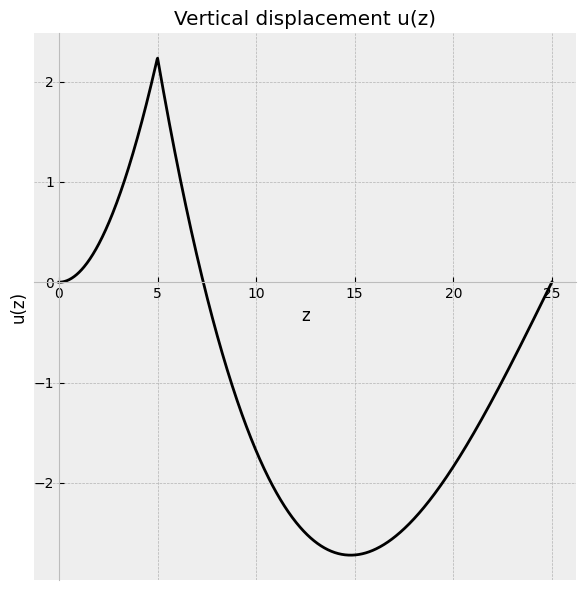

In [25]:
# Plotting u(z) shape
smp.plot(u.subs(subs), (z, 0, 25),
         title = "Vertical displacement u(z)",
         xlabel = "z",
         ylabel = "u(z)",
         line_color = "black",
         size = (6, 6))

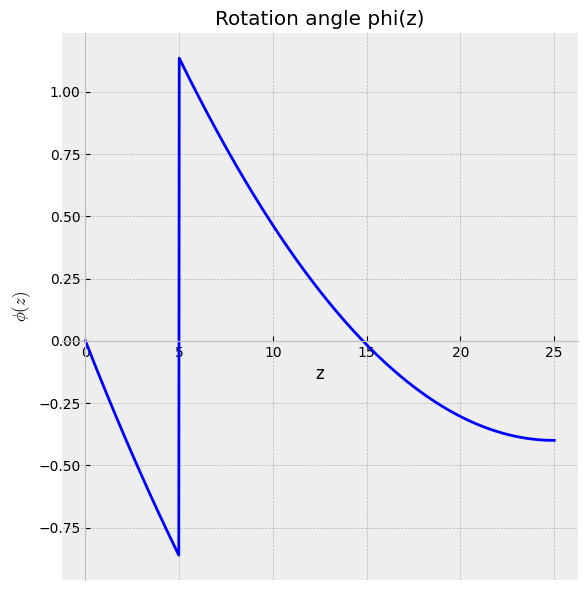

In [26]:
# Plotting phi(z) shape
smp.plot(phi.subs(subs), (z, 0, 25),
         title = "Rotation angle phi(z)",
         xlabel = "z",
         ylabel = "$\\phi(z)$",
         line_color = "blue",
         size = (6, 6))

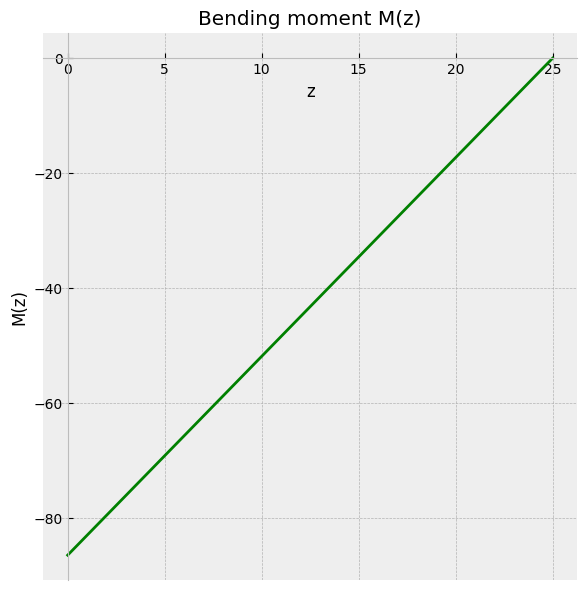

In [27]:
# Plotting M(z) shape
smp.plot(M.subs(subs), (z, 0, 25),
         title = "Bending moment M(z)",
         xlabel = "z",
         ylabel = "M(z)",
         line_color = "green",
         size = (6, 6))

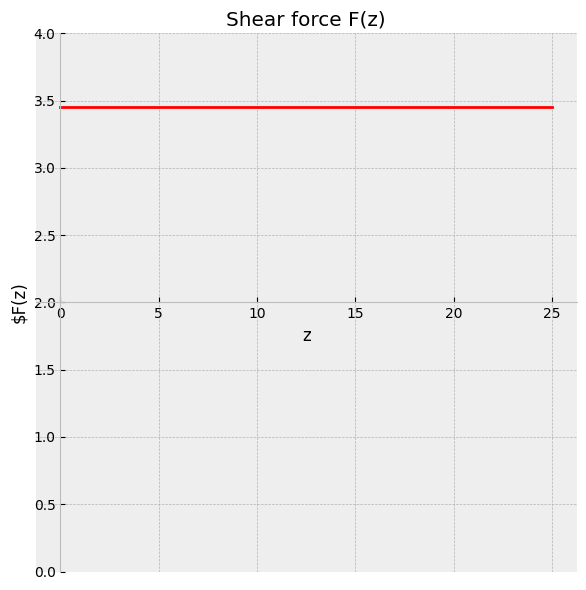

In [28]:
# Plotting F(z) shape
smp.plot(F.subs(subs), (z, 0, 25),
         title = "Shear force F(z)",
         xlabel = "z",
         ylabel = "$F(z)",
         line_color = "red",
         ylim = (0, 4),
         size = (6, 6))

Now, let's rewrite the solution of the problem in terms of $L$ and $k$, which represent the total span of the beam and the factor defining the location of the distortion along the beam, respectively:

$$
    L = L_1 + L_2 \quad L_1 = k \, L
$$

In [29]:
# Defining L and k factor
L, k = smp.symbols("L k", real = True, positive = True, constant = True)

subs = {
    L2: L * (1 - k),
    L1: k * L
}

In [30]:
# u1(z)
u1 = u1.subs(subs).simplify()
u1

D_{phi}*z**2*(-3*L*k + 3*L + k*z - z)/(2*L**2)

In [31]:
# u2(z)
u2 = u2.subs(subs).simplify()
u2

D_{phi}*(2*L**3*k - 2*L**2*z - 3*L*k*z**2 + 3*L*z**2 + k*z**3 - z**3)/(2*L**2)

In [32]:
# Displacement u(z)
u = u.subs(subs).simplify()
u

Piecewise((D_{phi}*z**2*(-3*L*k + 3*L + k*z - z)/(2*L**2), (z >= 0) & (z <= L*k)), (D_{phi}*(2*L**3*k - 2*L**2*z - 3*L*k*z**2 + 3*L*z**2 + k*z**3 - z**3)/(2*L**2), (L >= z) & (z > L*k)), (0, L < z))

In [33]:
# Angle phi(z)
phi = phi.subs(subs).simplify()
phi

Piecewise((3*D_{phi}*z*(2*L*k - 2*L - k*z + z)/(2*L**2), (z >= 0) & (z <= L*k)), (D_{phi}*(2*L**2 + 6*L*k*z - 6*L*z - 3*k*z**2 + 3*z**2)/(2*L**2), (z > L*k) & (L*k >= L*(k - 1) + z)), (0, L*k < L*(k - 1) + z))

In [34]:
# Bending moment M(z)
M = M.subs(subs).simplify()
M

Piecewise((3*D_{phi}*E*I*(L*k - L - k*z + z)/L**2, (z >= 0) & (L*k >= L*(k - 1) + z)), (0, L*k < L*(k - 1) + z))

In [35]:
# Shear Force F(z)
F = F.subs(subs).simplify()
F

Piecewise((3*D_{phi}*E*I*(1 - k)/L**2, (z >= 0) & (L*k >= L*(k - 1) + z)), (0, L*k < L*(k - 1) + z))